# Implementation of EfficientNetV2-S with Grad-CAM for Fetal Plane Classification

Dataset yang digunakan berasal dari Maternal–Fetal Plane Ultrasound Dataset yang tersedia secara publik di ZENODO. Terdapat 6 bidang utama:
1. Abdomen
2. Brain (subkategori: Trans-thalamic, Trans-cerebellum, Trans-ventricular)
3. Femur
4. Thorax
5. Maternal Cervix
6. Other

*   Model menggunakan **EfficientNetV2-S** sebagai backbone utama karena kemampuannya menyeimbangkan efisiensi komputasi dan akurasi tinggi.
*   Untuk memastikan hasil prediksi model dapat dijelaskan secara visual, digunakan metode **Grad-CAM (Gradient-weighted Class Activation Mapping)** sebagai alat interpretasi dan evaluasi visual.

# 1. Environment Setup

1. **TensorFlow dan Keras** untuk pemodelan CNN
2. **NumPy dan Pandas** untuk manipulasi data
3. **Matplotlib** untuk visualisasi
4. **OpenCV** untuk menampilkan hasil Grad-CAM

In [ ]:
import os
import random
from pathlib import Path
import json
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

print('TensorFlow version yang digunakan:', tf.__version__)


TensorFlow version yang digunakan: 2.20.0


# 2. Model Configuration

In [ ]:
NUM_CLASSES = 6
LAST_CONV_LAYER_NAME = 'top_conv'

# 3. Dataset Loading

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# User-specified paths
DATASET_DIR = "/content/drive/MyDrive/Dataset" if IN_COLAB else "data"
IMG_DIR     = DATASET_DIR + "/Images"
LABEL_FILE  = DATASET_DIR + "/FETAL_PLANES_DB_data.csv"

print('DATASET_DIR =', DATASET_DIR)
print('IMG_DIR =', IMG_DIR)
print('LABEL_FILE =', LABEL_FILE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATASET_DIR = /content/drive/MyDrive/Dataset
IMG_DIR = /content/drive/MyDrive/Dataset/Images
LABEL_FILE = /content/drive/MyDrive/Dataset/FETAL_PLANES_DB_data.csv


# 4. Data Assessment

In [ ]:
import pandas as pd

LABEL_FILE = "/content/drive/MyDrive/Dataset/FETAL_PLANES_DB_data.csv"
df = pd.read_csv(LABEL_FILE)

print("Kolom yang tersedia dalam file CSV:")
print(df.columns.tolist())

df.head()

Kolom yang tersedia dalam file CSV:
['Image_name;Patient_num;Plane;Brain_plane;Operator;US_Machine;Train ']


,Image_name;Patient_num;Plane;Brain_plane;Operator;US_Machine;Train
0,Patient00001_Plane1_1_of_15;1;Other;Not A Brai...
1,Patient00001_Plane1_2_of_15;1;Other;Not A Brai...
2,Patient00001_Plane1_3_of_15;1;Other;Not A Brai...
3,Patient00001_Plane1_4_of_15;1;Other;Not A Brai...
4,Patient00001_Plane1_5_of_15;1;Other;Not A Brai...


In [ ]:
print(df.columns.tolist())

['Image_name;Patient_num;Plane;Brain_plane;Operator;US_Machine;Train ']


In [ ]:
LABEL_FILE = "/content/drive/MyDrive/Dataset/FETAL_PLANES_DB_data.csv"
df = pd.read_csv(LABEL_FILE, sep=';')

df.columns = df.columns.str.strip()

print("Kolom yang tersedia:")
print(df.columns.tolist())

IMG_DIR = "/content/drive/MyDrive/Dataset/Images/"

df["image_path"] = df["Image_name"].apply(lambda x: os.path.join(IMG_DIR, f"{x}.png"))  # sesuaikan ekstensi

print(df[["Image_name", "Plane", "image_path"]].head())

Kolom yang tersedia:
['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train']
                    Image_name  Plane  \
0  Patient00001_Plane1_1_of_15  Other   
1  Patient00001_Plane1_2_of_15  Other   
2  Patient00001_Plane1_3_of_15  Other   
3  Patient00001_Plane1_4_of_15  Other   
4  Patient00001_Plane1_5_of_15  Other   

                                          image_path  
0  /content/drive/MyDrive/Dataset/Images/Patient0...  
1  /content/drive/MyDrive/Dataset/Images/Patient0...  
2  /content/drive/MyDrive/Dataset/Images/Patient0...  
3  /content/drive/MyDrive/Dataset/Images/Patient0...  
4  /content/drive/MyDrive/Dataset/Images/Patient0...  


In [ ]:
print("Jumlah gambar valid:", df["image_path"].notnull().sum())
print("Contoh path valid:\n", df["image_path"].dropna().head())

Jumlah gambar valid: 12400
Contoh path valid:
 0    /content/drive/MyDrive/Dataset/Images/Patient0...
1    /content/drive/MyDrive/Dataset/Images/Patient0...
2    /content/drive/MyDrive/Dataset/Images/Patient0...
3    /content/drive/MyDrive/Dataset/Images/Patient0...
4    /content/drive/MyDrive/Dataset/Images/Patient0...
Name: image_path, dtype: object


Kolom data: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train', 'image_path']


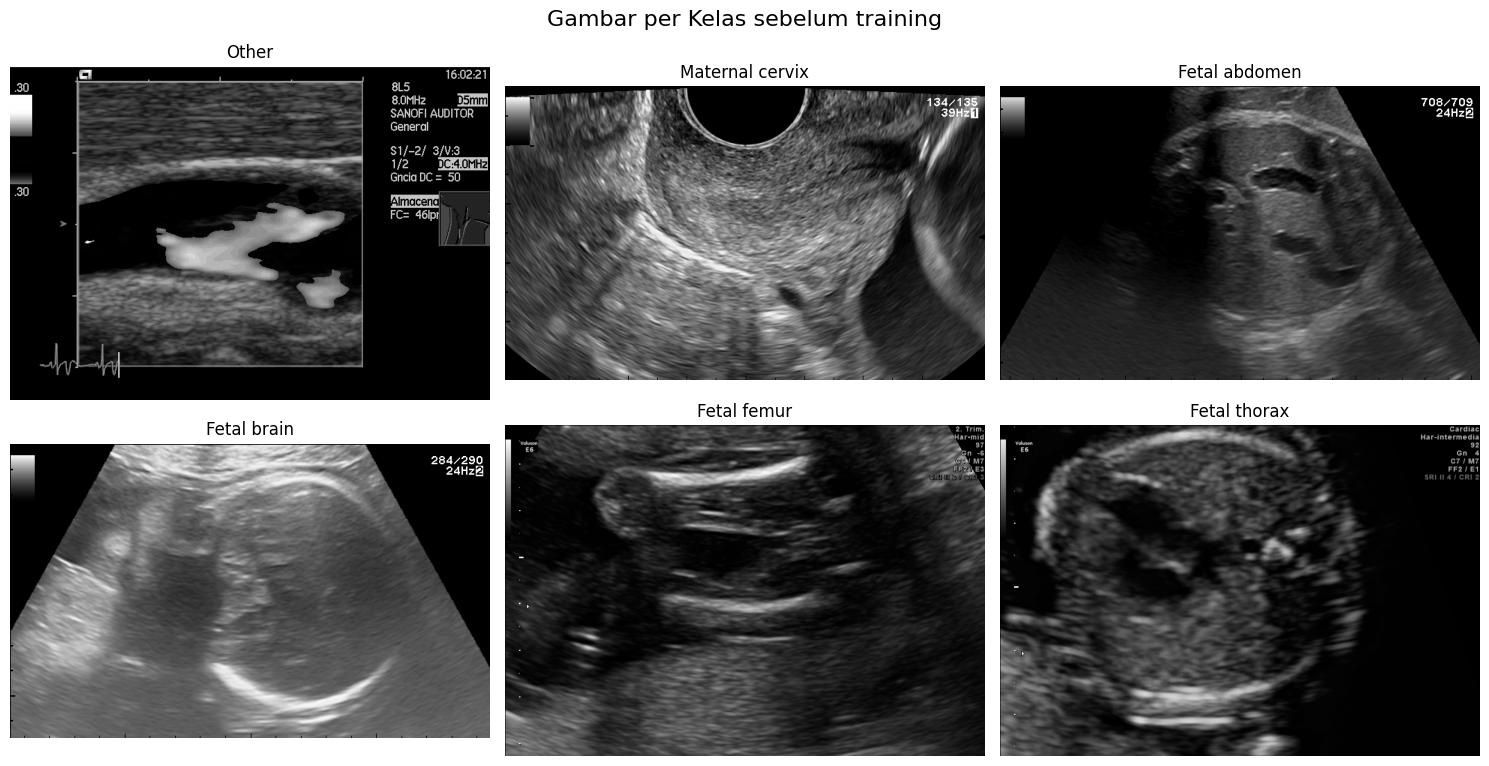

In [ ]:
IMG_DIR = "/content/drive/MyDrive/Dataset/Images"

# Pastikan data memiliki kolom 'Plane' dan 'Image_name'
print("Kolom data:", df.columns.tolist())

# Fungsi untuk mendeteksi ekstensi file yang sesuai (.jpg, .png, dll)
def find_image_path(name):
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        path = os.path.join(IMG_DIR, name + ext)
        if os.path.exists(path):
            return path
    return None

# Buat kolom baru 'image_path'
df["image_path"] = df["Image_name"].apply(find_image_path)

# Ambil satu contoh acak dari setiap kelas
classes = df["Plane"].unique()
sample_images = []

for cls in classes:
    sample = df[df["Plane"] == cls].sample(1, random_state=42)
    sample_images.append(sample.iloc[0])

# Plot 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Gambar per Kelas sebelum training", fontsize=16)

for ax, sample in zip(axes.flat, sample_images):
    img_path = sample["image_path"]
    label = sample["Plane"]
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(label, fontsize=12)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, "Gagal memuat", ha="center", va="center", fontsize=12)
        ax.set_title(label)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
classes = df["Plane"].unique()

for cls in classes[:6]:
    sample = df[df["Plane"] == cls].sample(1, random_state=42)
    idx = sample.index[0]
    path = sample["image_path"].values[0]

    img = cv2.imread(path)

    if img is not None:
        print(f"{cls} (Index {idx}):", img.shape)

Other (Index 643): (480, 692, 3)
Maternal cervix (Index 3810): (392, 640, 3)
Fetal abdomen (Index 10125): (392, 640, 3)
Fetal brain (Index 11482): (392, 640, 3)
Fetal femur (Index 3615): (661, 959, 3)
Fetal thorax (Index 4848): (661, 959, 3)


# 5. Exploratory Data Analysis (EDA)

In [ ]:
import seaborn as sns
from PIL import Image

LABEL_FILE = "/content/drive/MyDrive/Dataset/FETAL_PLANES_DB_data.csv"
IMG_DIR = "/content/drive/MyDrive/Dataset/Images"

print("Membaca file label CSV...")
data = pd.read_csv(LABEL_FILE, sep=';')
data.columns = [col.strip() for col in data.columns]  # hapus spasi jika ada

print(f"\nJumlah total data: {len(data)}")
print("\nLima baris pertama dataset:")
display(data.head())

print("\nInformasi struktur dataset:")
print(data.info())

Membaca file label CSV...

Jumlah total data: 12400

Lima baris pertama dataset:


,Image_name,Patient_num,Plane,Brain_plane,Operator,US_Machine,Train
0,Patient00001_Plane1_1_of_15,1,Other,Not A Brain,Other,Aloka,1
1,Patient00001_Plane1_2_of_15,1,Other,Not A Brain,Other,Aloka,1
2,Patient00001_Plane1_3_of_15,1,Other,Not A Brain,Other,Aloka,1
3,Patient00001_Plane1_4_of_15,1,Other,Not A Brain,Other,Aloka,1
4,Patient00001_Plane1_5_of_15,1,Other,Not A Brain,Other,Aloka,1



Informasi struktur dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12400 entries, 0 to 12399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Image_name   12400 non-null  object
 1   Patient_num  12400 non-null  int64 
 2   Plane        12400 non-null  object
 3   Brain_plane  12400 non-null  object
 4   Operator     12400 non-null  object
 5   US_Machine   12400 non-null  object
 6   Train        12400 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 678.3+ KB
None


In [ ]:
# Menambahkan path gambar dan memeriksa ketersediaannya
def find_image_path(name):
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        path = os.path.join(IMG_DIR, name + ext)
        if os.path.exists(path):
            return path
    return None

data["image_path"] = data["Image_name"].apply(find_image_path)

missing_files = data[data["image_path"].isnull()]
if len(missing_files) > 0:
    print(f"\n{len(missing_files)} file gambar tidak ditemukan:")
    display(missing_files.head())
else:
    print("\nSemua file gambar ditemukan di direktori.")


Semua file gambar ditemukan di direktori.


/tmp/ipykernel_7976/2502164698.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


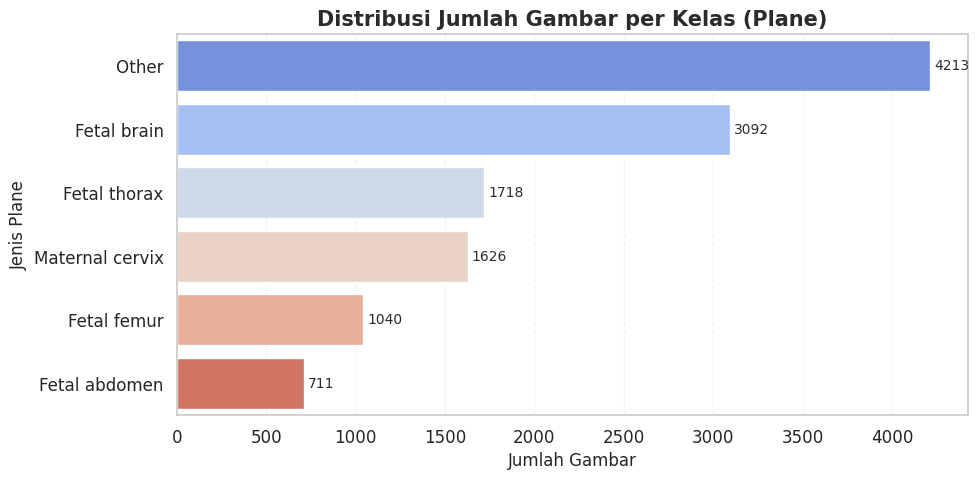

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", font_scale=1.1)
main_palette = "coolwarm"

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    y="Plane",
    data=data,
    order=data["Plane"].value_counts().index,
    palette=main_palette
)
plt.title("Distribusi Jumlah Gambar per Kelas (Plane)", fontsize=15, weight="bold", color="#2b2b2b")
plt.xlabel("Jumlah Gambar", fontsize=12)
plt.ylabel("Jenis Plane", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3, color="#2b2b2b")
plt.tight_layout()
plt.show()


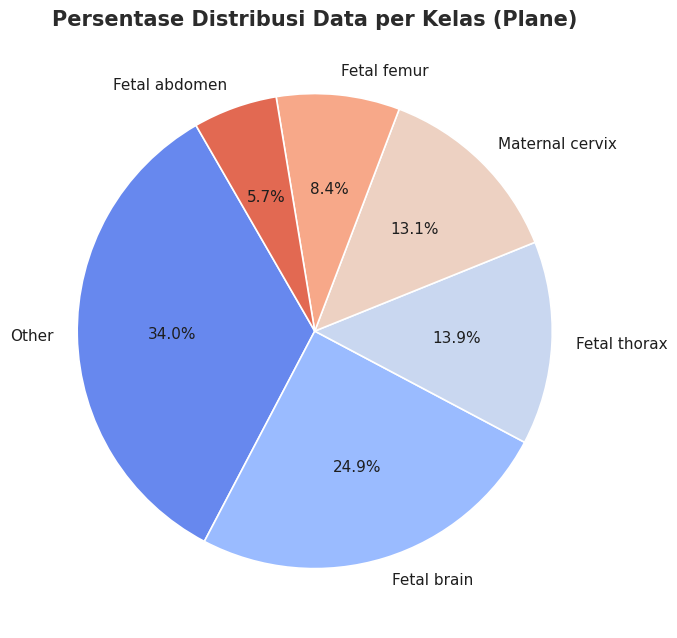

In [ ]:
# Pie Chart
plt.figure(figsize=(7, 7))
colors = sns.color_palette(main_palette, len(data["Plane"].unique()))
data["Plane"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=120,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 11, 'color': '#1e1e1e'}
)
plt.title("Persentase Distribusi Data per Kelas (Plane)", fontsize=15, weight="bold", color="#2b2b2b")
plt.ylabel("")  # hapus label default
plt.tight_layout()
plt.show()

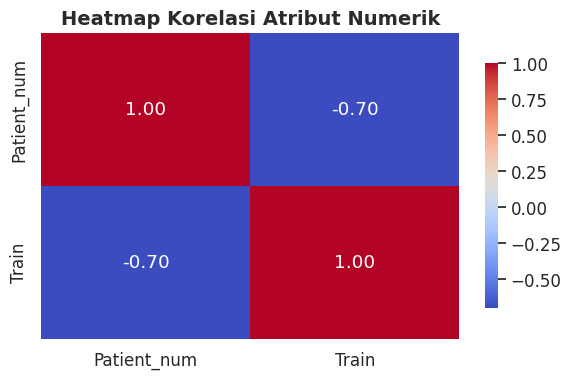

In [ ]:
# Analisis Korelasi Numerik
num_cols = data.select_dtypes(include=["int", "float"])
if num_cols.shape[1] > 1:
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        num_cols.corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        cbar_kws={'shrink': 0.8}
    )
    plt.title("Heatmap Korelasi Atribut Numerik", fontsize=14, weight="bold", color="#2b2b2b")
    plt.tight_layout()
    plt.show()

In [ ]:
# Pemeriksaan nilai unik dan data kosong
print("\nNilai unik label (Plane):", data["Plane"].unique())
print("\nJumlah nilai kosong per kolom:")
print(data.isnull().sum())


Nilai unik label (Plane): ['Other' 'Maternal cervix' 'Fetal abdomen' 'Fetal brain' 'Fetal femur'
 'Fetal thorax']

Jumlah nilai kosong per kolom:
Image_name     0
Patient_num    0
Plane          0
Brain_plane    0
Operator       0
US_Machine     0
Train          0
image_path     0
dtype: int64


In [ ]:
# Ringkasan EDA
num_classes = len(data["Plane"].unique())
is_balanced = data["Plane"].value_counts().std() < 0.1 * data["Plane"].value_counts().mean()

print(f"1. Dataset terdiri dari {num_classes} kelas citra fetal plane.")
print(f"2. Seluruh file gambar ditemukan dalam direktori: {IMG_DIR}.")
print(f"4. Tidak ditemukan nilai kosong pada kolom penting.")
print(f"5. Distribusi label tergolong {'seimbang' if is_balanced else 'tidak seimbang'}.")

1. Dataset terdiri dari 6 kelas citra fetal plane.
2. Seluruh file gambar ditemukan dalam direktori: /content/drive/MyDrive/Dataset/Images.
4. Tidak ditemukan nilai kosong pada kolom penting.
5. Distribusi label tergolong tidak seimbang.


In [ ]:
df = pd.read_csv(LABEL_FILE, sep=';')
df.columns = [col.strip() for col in df.columns]  # hapus spasi

def find_image_path(name):
    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        path = os.path.join(IMG_DIR, name + ext)
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df["Image_name"].apply(find_image_path)
missing_files = df[df["image_path"].isnull()]
if len(missing_files) > 0:
    print(f"{len(missing_files)} file gambar tidak ditemukan:")
    display(missing_files.head())
else:
    print("Semua file gambar ditemukan.")

Semua file gambar ditemukan.


# 6. Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

if 'Plane' in df.columns and 'image_path' in df.columns:
    if 'subset' in df.columns:
        train_df = df[df['subset']=='train'].reset_index(drop=True)
        val_df = df[df['subset']=='val'].reset_index(drop=True)
        test_df = df[df['subset']=='test'].reset_index(drop=True)
        print('Menggunakan kolom subset CSV untuk split')
    else:
        train_val, test_df = train_test_split(df, test_size=0.15, stratify=df['Plane'], random_state=42)
        train_df, val_df = train_test_split(train_val, test_size=0.1765, stratify=train_val['Plane'], random_state=42)
        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)
        print('Melakukan stratified split: train/val/test ~70/15/15')

    print('Ukuran: train/val/test =', len(train_df), len(val_df), len(test_df))
else:
    train_df = pd.DataFrame(); val_df = pd.DataFrame(); test_df = pd.DataFrame()

Melakukan stratified split: train/val/test ~70/15/15
Ukuran: train/val/test = 8679 1861 1860


# 7. Label Encoding

Proses mengubah label kategori (berupa teks) menjadi angka numerik agar bisa diproses oleh model deep learning.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
if not train_df.empty:
    label_encoder.fit(train_df['Plane'])
    CLASS_NAMES = list(label_encoder.classes_)
    NUM_CLASSES = len(CLASS_NAMES)
else:
    CLASS_NAMES = []
    NUM_CLASSES = 0

print('Detected classes:', CLASS_NAMES)

Detected classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']


# 8. Data Augmentation and Pre-Processing

a) Label encoding: ubah nama kelas jadi angka.

b) Shuffle: acak data agar distribusi seimbang.

c) Decode & resize: baca gambar dari path dan ubah ukurannya.

d) Set shape: tetapkan dimensi tensor.

e) Batching: kelompokkan gambar jadi satu batch.

f) Prefetching: siapkan batch berikutnya agar cepat.

g) Augmentasi: tambahkan variasi acak (hanya training).

h) Normalisasi: sesuaikan nilai pixel sesuai input model.

i) One-hot encoding: ubah label angka jadi vektor biner.

In [ ]:
BATCH_SIZE = 16
AUTO = tf.data.AUTOTUNE
IMAGE_SIZE = (224, 224)
NUM_CLASSES = len(df["Plane"].unique())

In [ ]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
], name="augmenter")

In [ ]:
# image decoding and resizing
def decode_and_resize(path, label):
    path = path.numpy().decode('utf-8')
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMAGE_SIZE)
    image = image.astype(np.float32)
    return image, label

# mengecek dataframe
def prepare_dataset(df, batch_size=BATCH_SIZE, is_training=True):
    if df.empty:
        return None

# label encoding
    paths = df['image_path'].values
    labels = label_encoder.transform(df['Plane'].values)

# dataset creation and shuffling (input pipeline)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_training:
        ds = ds.shuffle(buffer_size=len(paths))

# decode and resize
    ds = ds.map(lambda p, l: tf.py_function(func=decode_and_resize, inp=[p,l], Tout=[tf.float32, tf.int64]),
                num_parallel_calls=AUTO)

# set shape
    def set_shape(image, label):
        image.set_shape(list(IMAGE_SIZE) + [3])
        label.set_shape([])
        return image, label
    ds = ds.map(set_shape, num_parallel_calls=AUTO)

# batching and prefetching
    ds = ds.batch(batch_size).prefetch(AUTO)

# data augmentation (hanya untuk data training)
    if is_training:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=AUTO)

# normalisasi and one hot encoding
    ds = ds.map(lambda x, y: (preprocess_input(x), tf.one_hot(y, NUM_CLASSES)), num_parallel_calls=AUTO)

    return ds

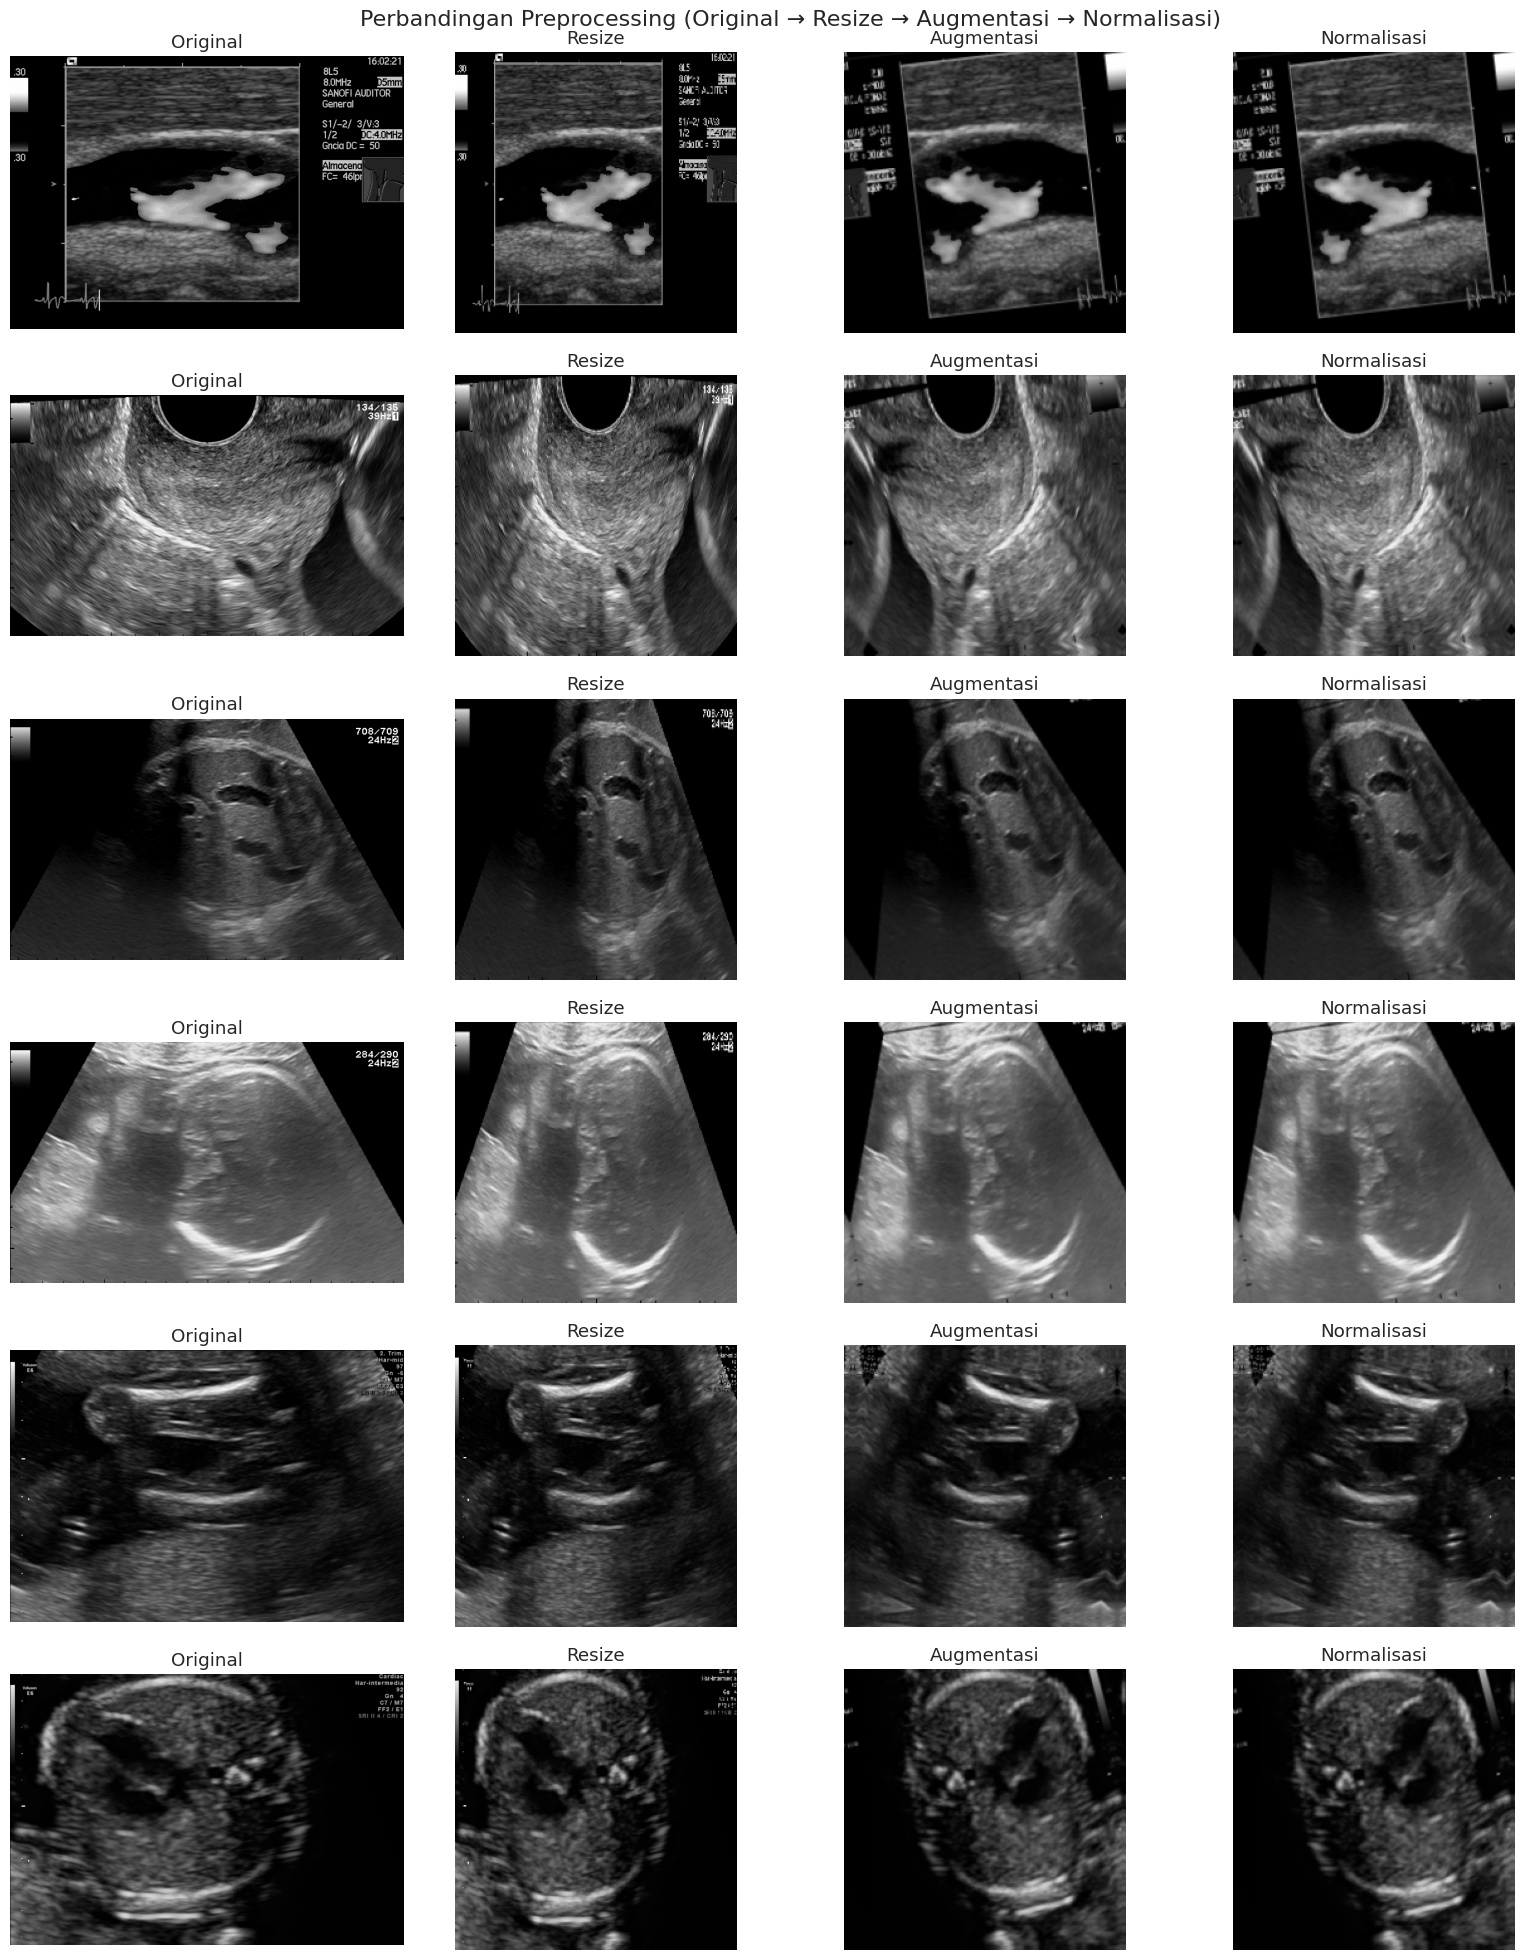

In [ ]:
classes = df["Plane"].unique()
sample_images = []

for cls in classes[:6]:
    sample = df[df["Plane"] == cls].sample(1, random_state=42)
    sample_images.append(sample.iloc[0])

fig, axes = plt.subplots(6, 4, figsize=(16, 20))
fig.suptitle("Perbandingan Preprocessing (Original → Resize → Augmentasi → Normalisasi)", fontsize=16)

IMG_SIZE = (224, 224)

for row_idx, sample in enumerate(sample_images):
    img_name = sample["Image_name"]
    img_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        potential_path = os.path.join(IMG_DIR, img_name + ext)
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path and os.path.exists(img_path):
        # 1. ORIGINAL
        img = tf.keras.utils.load_img(img_path)
        img_array = tf.keras.utils.img_to_array(img)

        axes[row_idx, 0].imshow(img_array.astype("uint8"))
        axes[row_idx, 0].set_title("Original")
        axes[row_idx, 0].axis("off")

        # 2. RESIZE
        resized = tf.image.resize(img_array, IMG_SIZE)

        axes[row_idx, 1].imshow(resized.numpy().astype("uint8"))
        axes[row_idx, 1].set_title("Resize")
        axes[row_idx, 1].axis("off")

        # 3. AUGMENTASI
        img_batch = tf.expand_dims(resized, 0)
        aug_img = augmenter(img_batch)

        aug_img = tf.squeeze(aug_img)

        axes[row_idx, 2].imshow(aug_img.numpy().astype("uint8"))
        axes[row_idx, 2].set_title("Augmentasi")
        axes[row_idx, 2].axis("off")

        # 4. NORMALISASI
        norm_img = aug_img / 255.0

        axes[row_idx, 3].imshow(norm_img.numpy())
        axes[row_idx, 3].set_title("Normalisasi")
        axes[row_idx, 3].axis("off")

    else:
        for col in range(4):
            axes[row_idx, col].text(0.5, 0.5, "Gagal memuat", ha="center", va="center")
            axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()

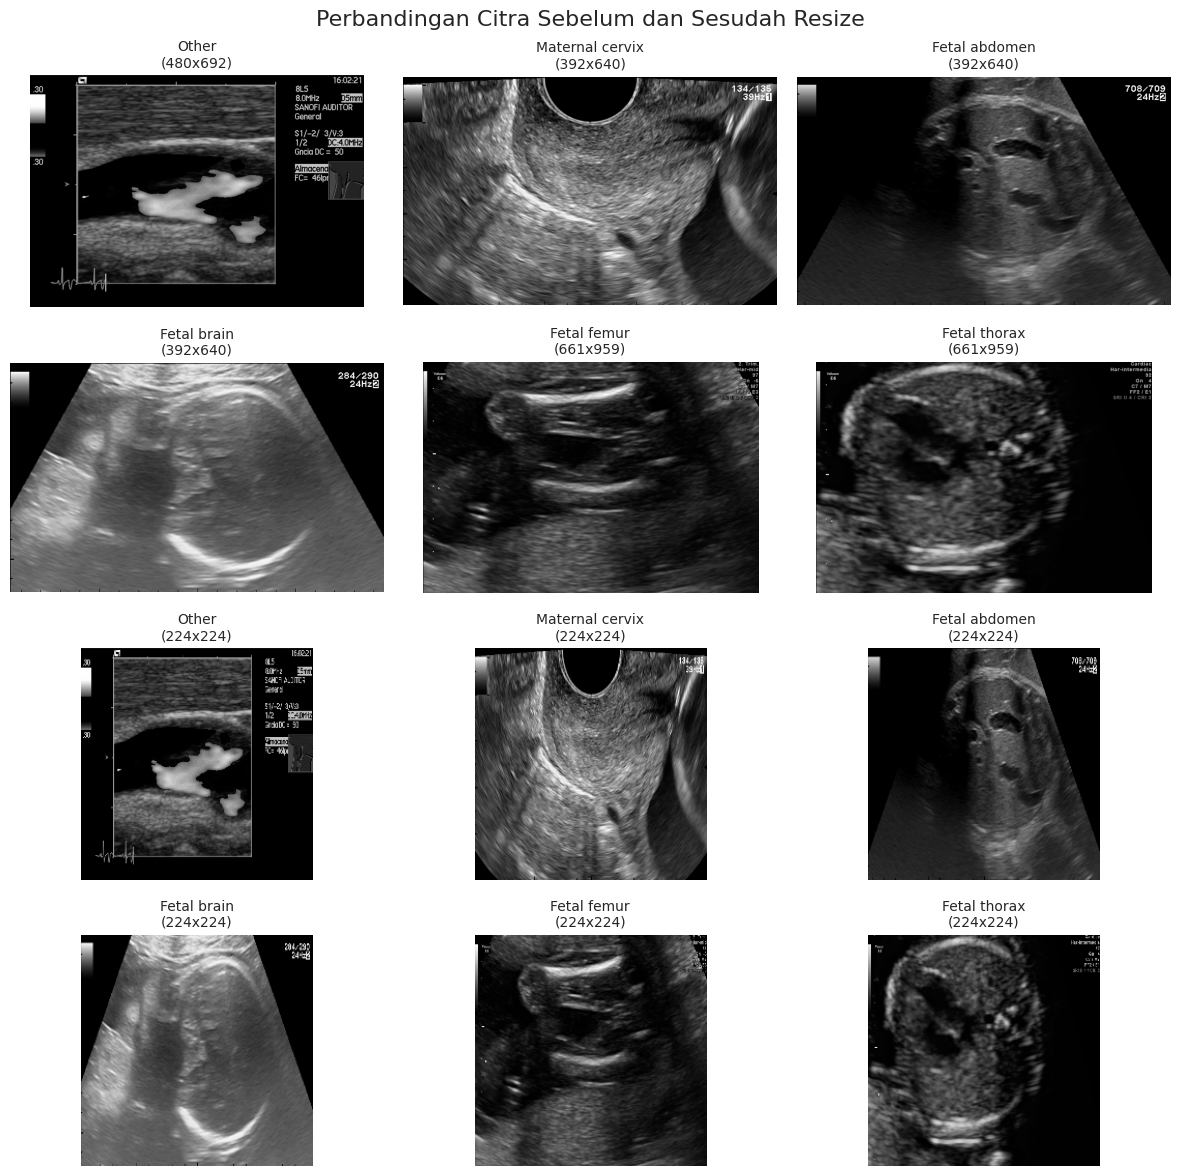

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
fig.suptitle("Perbandingan Citra Sebelum dan Sesudah Resize", fontsize=16)

IMG_SIZE = (224, 224)

for idx, sample in enumerate(sample_images):
    row_before = idx // 3          # 0 atau 1
    row_after = row_before + 2     # 2 atau 3
    col = idx % 3

    img_name = sample["Image_name"]
    label = sample["Plane"]
    img_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        potential_path = os.path.join(IMG_DIR, img_name + ext)
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path:
        img = tf.keras.utils.load_img(img_path)
        img_array = tf.keras.utils.img_to_array(img).astype("uint8")

        h, w, _ = img_array.shape

        # BEFORE (SEMUA DI ATAS)
        axes[row_before, col].imshow(img_array)
        axes[row_before, col].set_title(f"{label}\n({h}x{w})", fontsize=10)
        axes[row_before, col].axis("off")

        # AFTER (SEMUA DI BAWAH)
        resized = tf.image.resize(img_array, IMG_SIZE).numpy().astype("uint8")

        axes[row_after, col].imshow(resized)
        axes[row_after, col].set_title(f"{label}\n(224x224)", fontsize=10)
        axes[row_after, col].axis("off")

plt.tight_layout()
plt.show()

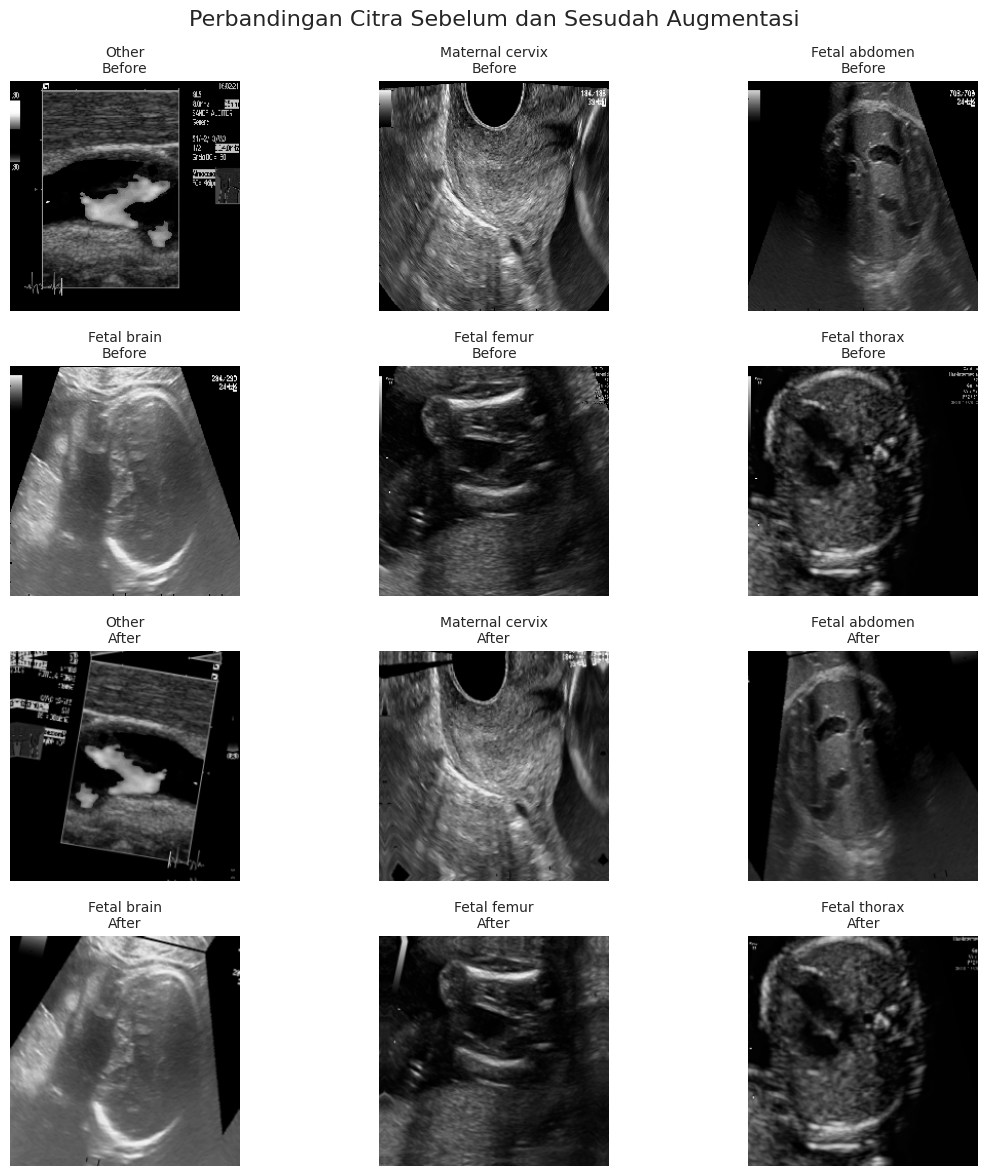

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
fig.suptitle("Perbandingan Citra Sebelum dan Sesudah Augmentasi", fontsize=16)

IMG_SIZE = (224, 224)

for idx, sample in enumerate(sample_images):
    row_before = idx // 3
    row_after = row_before + 2
    col = idx % 3

    img_name = sample["Image_name"]
    label = sample["Plane"]
    img_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        potential_path = os.path.join(IMG_DIR, img_name + ext)
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path:
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img).astype("uint8")

        # BEFORE
        axes[row_before, col].imshow(img_array)
        axes[row_before, col].set_title(f"{label}\nBefore", fontsize=10)
        axes[row_before, col].axis("off")

        # AFTER (AUGMENTASI)
        img_batch = tf.expand_dims(img_array, 0)
        aug_img = augmenter(img_batch)
        aug_img = tf.squeeze(aug_img).numpy().astype("uint8")

        axes[row_after, col].imshow(aug_img)
        axes[row_after, col].set_title(f"{label}\nAfter", fontsize=10)
        axes[row_after, col].axis("off")

plt.tight_layout()
plt.show()

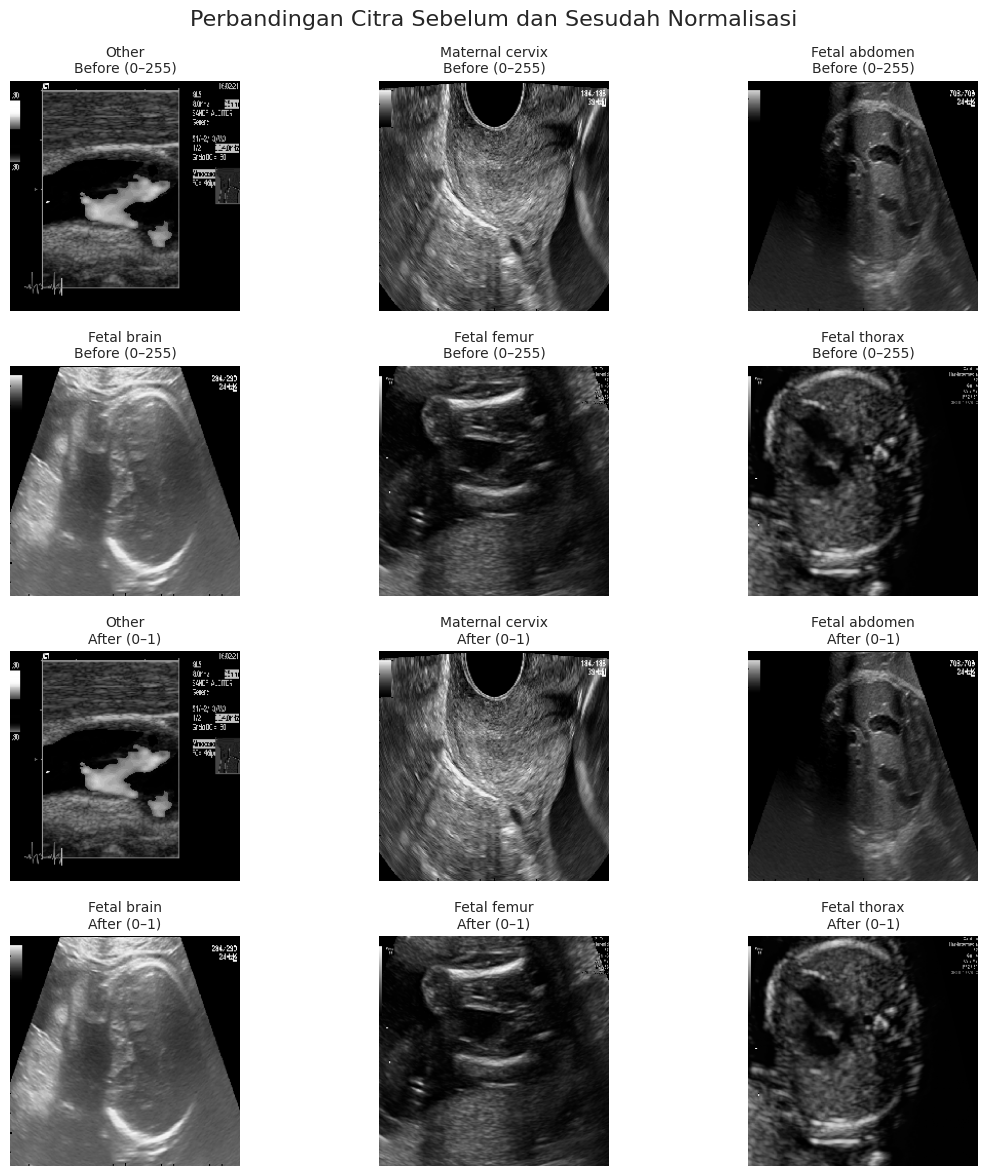

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
fig.suptitle("Perbandingan Citra Sebelum dan Sesudah Normalisasi", fontsize=16)

IMG_SIZE = (224, 224)

for idx, sample in enumerate(sample_images):
    row_before = idx // 3
    row_after = row_before + 2
    col = idx % 3

    img_name = sample["Image_name"]
    label = sample["Plane"]
    img_path = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
        potential_path = os.path.join(IMG_DIR, img_name + ext)
        if os.path.exists(potential_path):
            img_path = potential_path
            break

    if img_path:
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img).astype("uint8")

        # BEFORE
        axes[row_before, col].imshow(img_array)
        axes[row_before, col].set_title(f"{label}\nBefore (0–255)", fontsize=10)
        axes[row_before, col].axis("off")

        # AFTER (NORMALISASI)
        norm_img = img_array / 255.0

        axes[row_after, col].imshow(norm_img)
        axes[row_after, col].set_title(f"{label}\nAfter (0–1)", fontsize=10)
        axes[row_after, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_ds = prepare_dataset(train_df, BATCH_SIZE, is_training=True)
val_ds = prepare_dataset(val_df, BATCH_SIZE, is_training=False)
test_ds = prepare_dataset(test_df, BATCH_SIZE, is_training=False)

In [ ]:
if train_ds is not None:
    for xb, yb in train_ds.take(1):
        print('Sample batch shapes - images:', xb.shape, 'labels:', yb.shape)
        break

Sample batch shapes - images: (16, 224, 224, 3) labels: (16, 6)


# 9. Model Construction

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout,
    Dense
)

def create_model(input_shape, num_classes):
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze backbone INI
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='swish')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

# 10. Model Training

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Phase 1 Training (Head Layers Only)...
Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 1080s 2s/step - accuracy: 0.8220 - loss: 0.8198 - val_accuracy: 0.8571 - val_loss: 0.7241
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.8697 - loss: 0.7253 - val_accuracy: 0.8737 - val_loss: 0.6966
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.8818 - loss: 0.7065 - val_accuracy: 0.8834 - val_loss: 0.6793
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.8905 - loss: 0.6876 - val_accuracy: 0.8963 - val_loss: 0.6679
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8993 - loss: 0.6736 - val_accuracy: 0.9001 - val_loss: 0.6663
Epoch 6/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9077 - loss: 0.6622 - val_accuracy: 0.9054 - val_loss: 0.6574
Epoch 7/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9014 - loss: 0.6679 - val_accuracy: 0.9044 - val_los

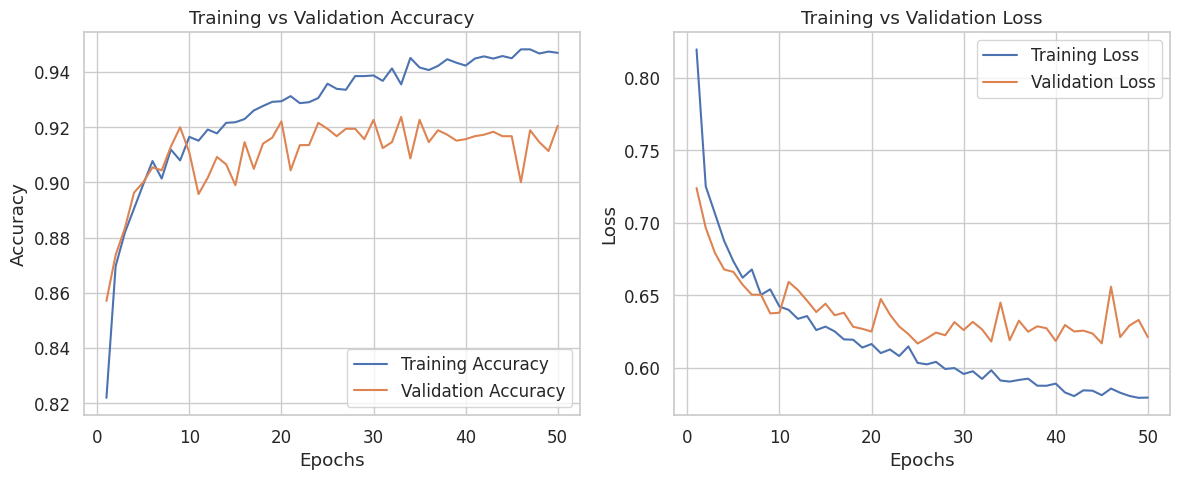

In [ ]:
from tensorflow.keras.optimizers import Adam

INPUT_SHAPE = IMAGE_SIZE + (3,)
model = create_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

EPOCHS_PHASE_1 = 50

print("\nStarting Phase 1 Training (Head Layers Only)...")
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_1
)

hist = history_1.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, hist["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist["loss"], label="Training Loss")
plt.plot(epochs_range, hist["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Evaluasi cepat pada data testing...
117/117 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9263 - loss: 0.5977

Test Accuracy: 0.9263

Classification Report:
                 precision    recall  f1-score   support

  Fetal abdomen       0.90      0.72      0.80       106
    Fetal brain       0.98      1.00      0.99       464
    Fetal femur       0.90      0.78      0.83       156
   Fetal thorax       0.89      0.89      0.89       258
Maternal cervix       1.00      1.00      1.00       244
          Other       0.88      0.93      0.91       632

       accuracy                           0.93      1860
      macro avg       0.93      0.89      0.90      1860
   weighted avg       0.93      0.93      0.93      1860



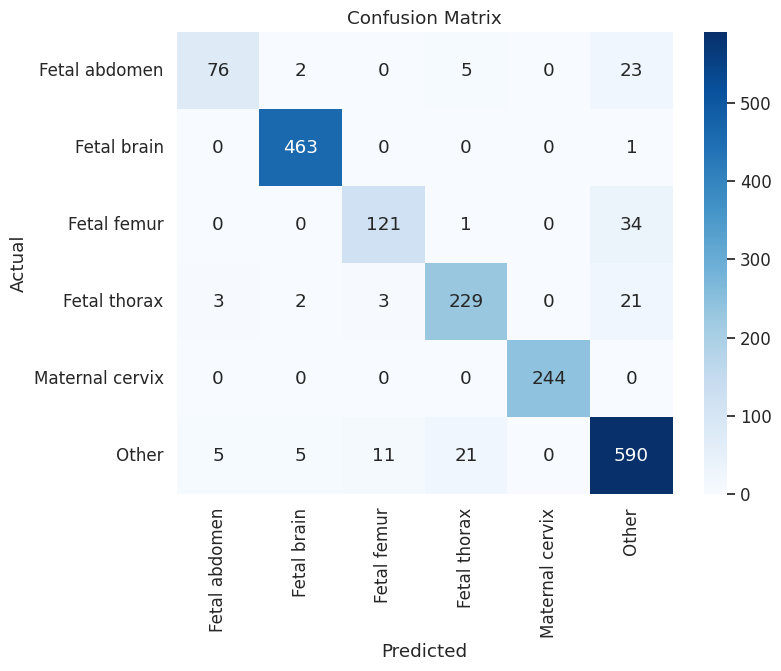

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Evaluasi cepat pada data testing...")

# 1. Evaluate langsung (cepat)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")

# 2. Predict sekaligus (lebih cepat dari loop)
y_pred_probs = model.predict(test_ds, verbose=0)

# 3. Ambil label asli langsung dari dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# 4. Prediksi akhir
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf

gpu_available = len(tf.config.list_physical_devices('GPU'))
print(f"Number of GPUs Available: {gpu_available}")

if gpu_available > 0:
    print("GPU is detected and available.")
    print("GPU Name:", tf.config.list_physical_devices('GPU')[0].name)
else:
    print("No GPU is detected or available.")

Number of GPUs Available: 1
GPU is detected and available.
GPU Name: /physical_device:GPU:0


# 11. Fine-tuning

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 21,319,796 (81.33 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

 Optimizer params: 658,958 (2.51 MB)

In [ ]:
print("Starting Fine-Tuning Phase...")

# Buka semua layer dulu
for layer in model.layers:
    layer.trainable = True

# Cari index top_conv (akhir backbone)
top_conv_index = None
for i, layer in enumerate(model.layers):
    if layer.name == "top_conv":
        top_conv_index = i
        break

print("Top conv index:", top_conv_index)

# Freeze 60% layer sebelum top_conv
fine_tune_at = int(top_conv_index * 0.5)

for layer in model.layers[:fine_tune_at]:
    layer.trainable = False

# Jangan train BatchNorm
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

Starting Fine-Tuning Phase...
Top conv index: 510


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-6,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [ ]:
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_ft
)

Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 166s 175ms/step - accuracy: 0.9982 - loss: 0.4442 - val_accuracy: 0.9522 - val_loss: 0.5270 - learning_rate: 1.0000e-06
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.9975 - loss: 0.4454 - val_accuracy: 0.9527 - val_loss: 0.5273 - learning_rate: 1.0000e-06
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - accuracy: 0.9977 - loss: 0.4452 - val_accuracy: 0.9522 - val_loss: 0.5276 - learning_rate: 1.0000e-06
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - accuracy: 0.9980 - loss: 0.4441 - val_accuracy: 0.9506 - val_loss: 0.5275 - learning_rate: 1.0000e-06
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - accuracy: 0.9980 - loss: 0.4441 - val_accuracy: 0.9516 - val_loss: 0.5267 - learning_rate: 1.0000e-06
Epoch 6/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - accuracy: 0.9978 - loss: 0.4445 - val_accuracy: 0.9511 - val_loss: 0.5269 - learning_rate: 1.0000e-06
Epoch 7/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/s

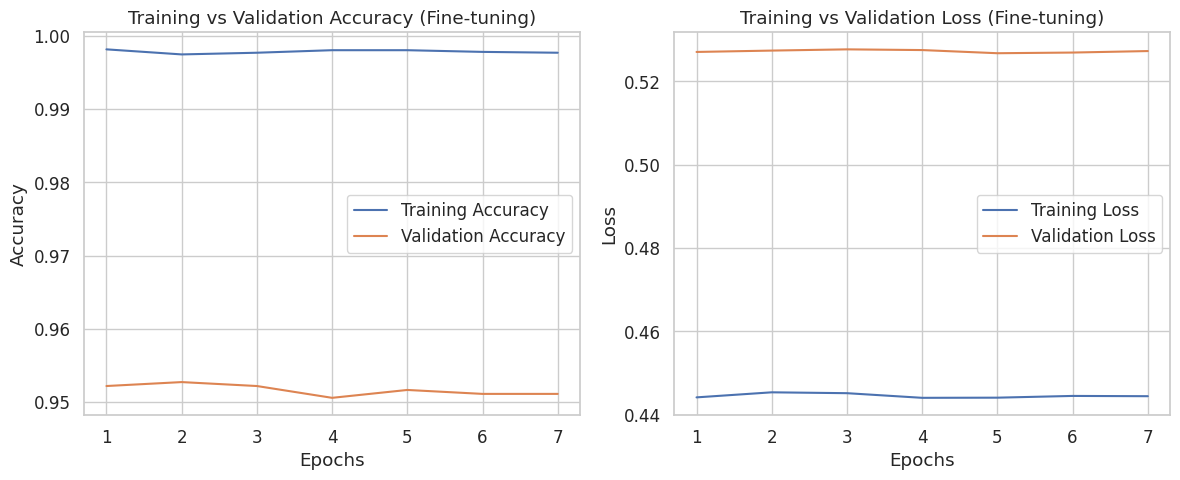

In [ ]:
hist_2 = history_2.history
epochs_range = range(1, len(hist_2["accuracy"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_2["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, hist_2["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy (Fine-tuning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_2["loss"], label="Training Loss")
plt.plot(epochs_range, hist_2["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss (Fine-tuning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 12. Model Evaluation

Evaluasi model menggunakan data testing untuk mengukur performa model pada data yang belum pernah dilihat sebelumnya. Metrik yang digunakan meliputi Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

Evaluasi cepat pada data testing...
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.9586 - loss: 0.5122

Test Accuracy: 0.9586

Classification Report:
                 precision    recall  f1-score   support

  Fetal abdomen       0.90      0.90      0.90       106
    Fetal brain       0.98      1.00      0.99       464
    Fetal femur       0.92      0.90      0.91       156
   Fetal thorax       0.95      0.96      0.95       258
Maternal cervix       1.00      1.00      1.00       244
          Other       0.95      0.94      0.94       632

       accuracy                           0.96      1860
      macro avg       0.95      0.95      0.95      1860
   weighted avg       0.96      0.96      0.96      1860



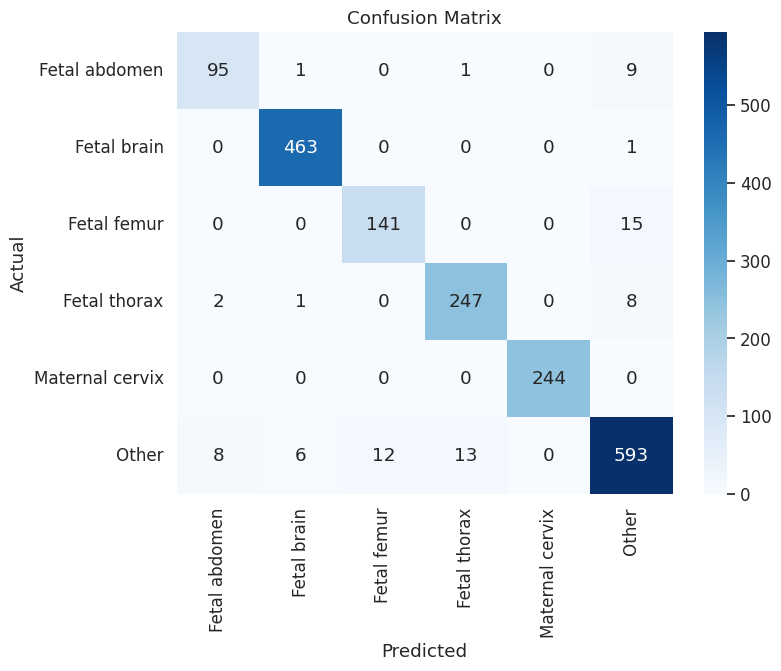

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Evaluasi cepat pada data testing...")

# 1. Evaluate langsung (cepat)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")

# 2. Predict sekaligus (lebih cepat dari loop)
y_pred_probs = model.predict(test_ds, verbose=0)

# 3. Ambil label asli langsung dari dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# 4. Prediksi akhir
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Menampilkan Gambar, True Label, dan Predicted Label untuk beberapa sampel testing:
----------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


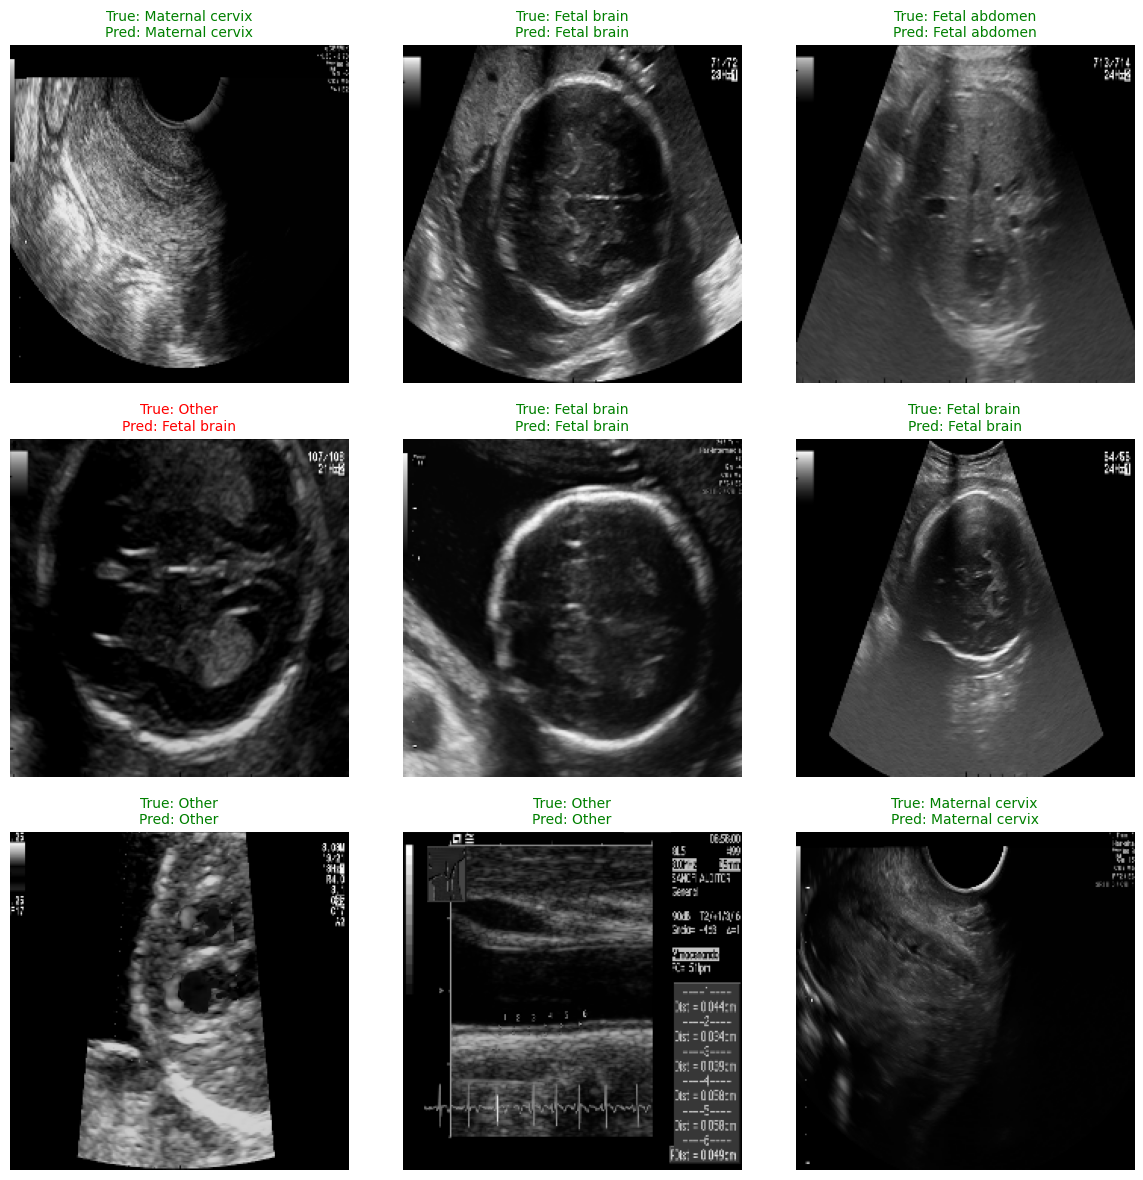

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Pastikan semua variabel sudah tersedia
if 'test_ds' in globals() and test_ds is not None and \
   'model' in globals() and model is not None and \
   'CLASS_NAMES' in globals() and 'label_encoder' in globals():

    print("Menampilkan Gambar, True Label, dan Predicted Label untuk beberapa sampel testing:")
    print("-" * 70)

    num_samples_to_show = 9  # jumlah gambar yang mau ditampilkan
    images_to_show = []
    true_labels_to_show = []
    pred_labels_to_show = []

    for images, labels in test_ds:
        # Prediksi
        predictions = model.predict(images)

        # Konversi one-hot → indeks
        true_indices = tf.argmax(labels, axis=1).numpy()
        pred_indices = tf.argmax(predictions, axis=1).numpy()

        # Konversi indeks → nama kelas
        true_names = label_encoder.inverse_transform(true_indices)
        pred_names = label_encoder.inverse_transform(pred_indices)

        # Simpan data untuk visualisasi
        for img, true_label, pred_label in zip(images, true_names, pred_names):
            images_to_show.append(img)
            true_labels_to_show.append(true_label)
            pred_labels_to_show.append(pred_label)
            if len(images_to_show) >= num_samples_to_show:
                break
        if len(images_to_show) >= num_samples_to_show:
            break

    # Tampilkan hasilnya dalam grid 3x3
    plt.figure(figsize=(12, 12))
    for i in range(num_samples_to_show):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images_to_show[i].numpy().astype("uint8"))
        true_label = true_labels_to_show[i]
        pred_label = pred_labels_to_show[i]

        # Warna hijau jika benar, merah jika salah
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("❌ ERROR: Variabel test_ds, model, CLASS_NAMES, atau label_encoder belum tersedia.")
    print("Pastikan semua langkah sebelumnya sudah dijalankan (splitting, encoding, training).")


In [ ]:
print("\n" + "="*50)
print("STATUS LAPISAN SETELAH PENGATURAN FINE-TUNING")
print("="*50)

if 'model' in globals() and model is not None:
    for layer in model.layers:
        # Check if it's the base model layer (functional_1) or other layers
        if 'functional_1' in layer.name:
            print(f"Layer: {layer.name:<40} Trainable: {layer.trainable} (MODEL UTAMA / EFFICIENTNETV2S)")
            # Iterate through sub-layers of the base model
            for sub_layer in layer.layers:
                 print(f"  > Sub-Layer: {sub_layer.name:<30} Trainable: {sub_layer.trainable}")
        else:
            # Custom layers (pooling, norm, dropout, dense)
            print(f"Layer: {layer.name:<40} Trainable: {layer.trainable} (KUSTOM)")

    print("\n" + "="*50)
    print("RINCIAN: Lapisan kustom (pooling, norm, dropout, dense) yang Anda buat selalu trainable (saat fine-tuning).")
    print("RINCIAN: Lapisan EfficientNetV2S unfrozen, jadi banyak sub-lapisan yang 'Trainable: True'.")
    print("="*50)

else:
    print("Variabel 'model' belum didefinisikan atau None. Pastikan Anda sudah menjalankan langkah pembuatan dan pelatihan model.")


STATUS LAPISAN SETELAH PENGATURAN FINE-TUNING
Layer: input_layer_1                            Trainable: False (KUSTOM)
Layer: rescaling                                Trainable: False (KUSTOM)
Layer: stem_conv                                Trainable: False (KUSTOM)
Layer: stem_bn                                  Trainable: False (KUSTOM)
Layer: stem_activation                          Trainable: False (KUSTOM)
Layer: block1a_project_conv                     Trainable: False (KUSTOM)
Layer: block1a_project_bn                       Trainable: False (KUSTOM)
Layer: block1a_project_activation               Trainable: False (KUSTOM)
Layer: block1a_add                              Trainable: False (KUSTOM)
Layer: block1b_project_conv                     Trainable: False (KUSTOM)
Layer: block1b_project_bn                       Trainable: False (KUSTOM)
Layer: block1b_project_activation               Trainable: False (KUSTOM)
Layer: block1b_drop                             Trainable: False 

# 13. Save Model

### Alternative Download Method (for slow downloads)

If downloading directly from the file browser is slow, you can try executing the following cell to initiate the download programmatically. This can sometimes offer better performance or at least give you an indication that the download is in progress.

In [ ]:
from google.colab import files

model_filename = 'fetal_plane_model.keras'

if os.path.exists(model_filename):
    print(f"Initiating download for {model_filename}...")
    files.download(model_filename)
    print("Download initiated. Check your browser's download manager.")
else:
    print(f"Error: Model file '{model_filename}' not found. Please ensure the model was saved correctly.")

Error: Model file 'fetal_plane_model.keras' not found. Please ensure the model was saved correctly.


In [ ]:
model.save('fetal_plane_model.keras')
model = tf.keras.models.load_model('fetal_plane_model.keras', compile=True)

In [ ]:
model.save('/content/drive/MyDrive/SKRIPSI/fetal_plane_model_skenario_enamlagi.keras')

# 14. GRAD-CAM

In [ ]:
last_conv_layer_name = "top_conv"

In [ ]:
for layer in model.layers:
    if "conv" in layer.name:
        print(layer.name)

stem_conv
block1a_project_conv
block1b_project_conv
block2a_expand_conv
block2a_project_conv
block2b_expand_conv
block2b_project_conv
block2c_expand_conv
block2c_project_conv
block2d_expand_conv
block2d_project_conv
block3a_expand_conv
block3a_project_conv
block3b_expand_conv
block3b_project_conv
block3c_expand_conv
block3c_project_conv
block3d_expand_conv
block3d_project_conv
block4a_expand_conv
block4a_dwconv2
block4a_project_conv
block4b_expand_conv
block4b_dwconv2
block4b_project_conv
block4c_expand_conv
block4c_dwconv2
block4c_project_conv
block4d_expand_conv
block4d_dwconv2
block4d_project_conv
block4e_expand_conv
block4e_dwconv2
block4e_project_conv
block4f_expand_conv
block4f_dwconv2
block4f_project_conv
block5a_expand_conv
block5a_dwconv2
block5a_project_conv
block5b_expand_conv
block5b_dwconv2
block5b_project_conv
block5c_expand_conv
block5c_dwconv2
block5c_project_conv
block5d_expand_conv
block5d_dwconv2
block5d_project_conv
block5e_expand_conv
block5e_dwconv2
block5e_projec

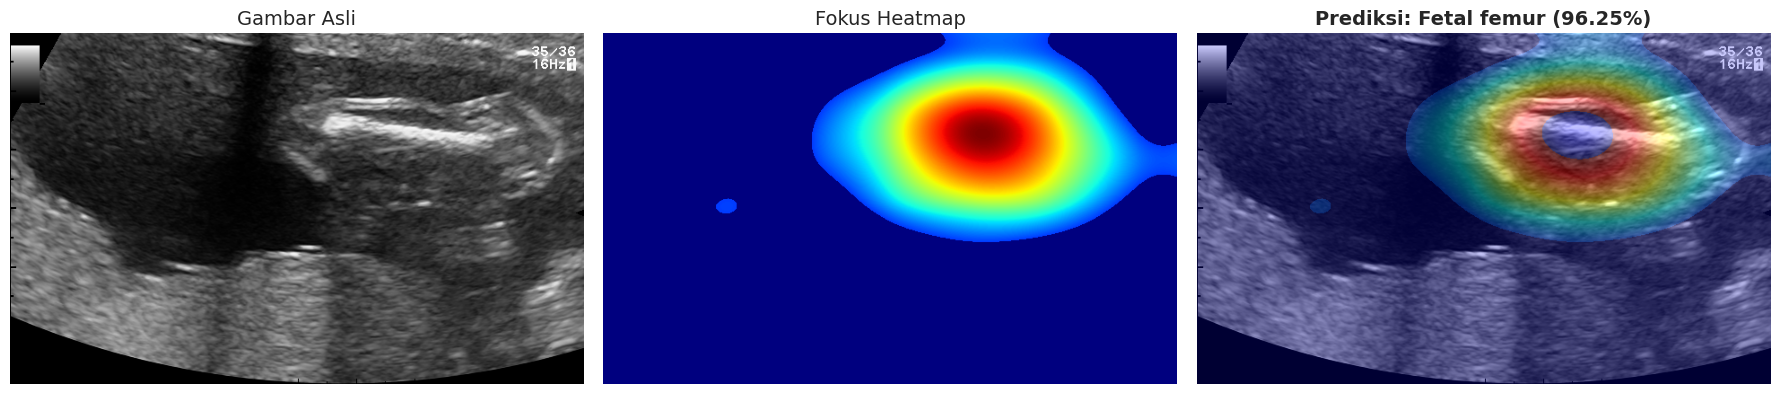

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

PATH_GAMBAR = "/content/drive/MyDrive/Dataset/Images/Patient00168_Plane5_2_of_2.png"

def eksekusi_gradcam_cepat(img_path, model, grad_model, class_names):
    if not os.path.exists(img_path):
        print(f"File tidak ditemukan: {img_path}")
        return

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    img_input = cv2.resize(img_rgb, (224, 224))
    img_input = np.expand_dims(img_input, axis=0)
    img_input_processed = preprocess_input(img_input.copy())

    img_tensor = tf.convert_to_tensor(img_input_processed, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outs, preds = grad_model(img_tensor, training=False)
        idx = tf.argmax(preds[0])
        loss = preds[:, idx]

    grads = tape.gradient(loss, conv_outs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy()

    heatmap_res = cv2.resize(heatmap, (w, h), interpolation=cv2.INTER_CUBIC)
    heatmap_res[heatmap_res < 0.2] = 0

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 0.8, heatmap_color, 0.4, 0)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Gambar Asli", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_res, cmap='jet')
    plt.title("Fokus Heatmap", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Prediksi: {class_names[idx]} ({np.max(preds):.2%})", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

eksekusi_gradcam_cepat(PATH_GAMBAR, model, grad_model, CLASS_NAMES)

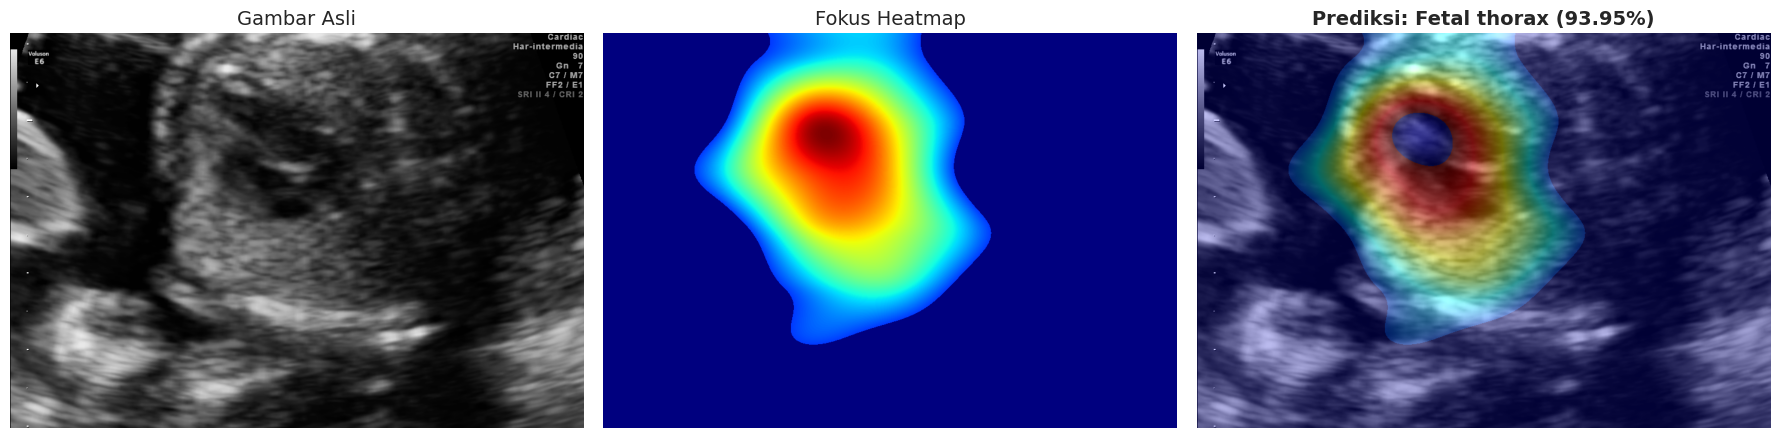

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

PATH_GAMBAR = "/content/drive/MyDrive/Dataset/Images/Patient00918_Plane6_2_of_4.png"

def eksekusi_gradcam_cepat(img_path, model, grad_model, class_names):
    if not os.path.exists(img_path):
        print(f"File tidak ditemukan: {img_path}")
        return

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    img_input = cv2.resize(img_rgb, (224, 224))
    img_input_processed = preprocess_input(img_input.copy())

    img_tensor = tf.convert_to_tensor(img_input_processed, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outs, preds = grad_model(img_tensor, training=False)
        idx = tf.argmax(preds[0])
        loss = preds[:, idx]

    grads = tape.gradient(loss, conv_outs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy()

    heatmap_res = cv2.resize(heatmap, (w, h), interpolation=cv2.INTER_CUBIC)
    heatmap_res[heatmap_res < 0.2] = 0

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 0.8, heatmap_color, 0.4, 0)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Gambar Asli", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_res, cmap='jet')
    plt.title("Fokus Heatmap", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Prediksi: {class_names[idx]} ({np.max(preds):.2%})", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

eksekusi_gradcam_cepat(PATH_GAMBAR, model, grad_model, CLASS_NAMES)